In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


C:\Users\marin\AppData\Local\Temp\ipykernel_17376\2578039198.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# ========= #
# 7. MODELO RIDGE #
# ========= #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', Ridge())
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 5469.1335199039995
RMSE: 7170.541103394506
MAPE: 0.04161253454058274
MAPE(%): 4.161253454058274
R2: 0.963104169466726


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
4203,14,4,5,Cloud Engineer,Master,Media,Small,Singapore,Yes,147842,155431.728367,-7589.728367,7589.728367
13442,15,19,0,Frontend Developer,Master,Media,Medium,Germany,Hybrid,161168,159268.828928,1899.171072,1899.171072
6092,15,18,1,Product Manager,Diploma,Healthcare,Large,Australia,No,170115,168838.485867,1276.514133,1276.514133
5418,1,9,5,Data Analyst,Master,Healthcare,Startup,Sweden,Yes,95140,85299.670886,9840.329114,9840.329114
17180,17,10,5,Backend Developer,Diploma,Government,Small,Germany,Yes,151130,153639.272966,-2509.272966,2509.272966
45873,11,10,2,Product Manager,Master,Government,Large,Singapore,No,165790,169009.631456,-3219.631456,3219.631456
2741,5,1,2,Software Engineer,Diploma,Retail,Medium,Sweden,Hybrid,101156,98450.389968,2705.610032,2705.610032
53648,6,17,0,Business Analyst,Diploma,Government,Medium,Canada,Hybrid,114145,120353.549008,-6208.549008,6208.549008
6237,20,18,0,Backend Developer,Master,Media,Large,UK,No,212511,199613.891606,12897.108394,12897.108394
13498,8,3,3,Business Analyst,Master,Telecom,Medium,Singapore,Hybrid,108557,106819.334691,1737.665309,1737.665309


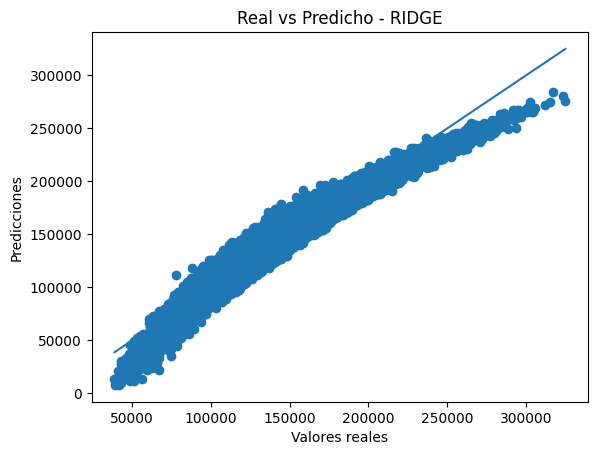

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - RIDGE")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


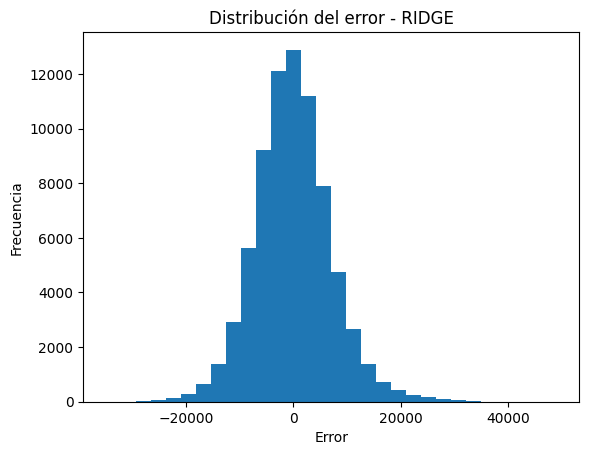

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - RIDGE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


In [13]:
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Definimos las métricas
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# 2. Ejecutamos la validación cruzada usando el nombre específico 'model_ridge'
cv_results = cross_validate(model, X_train, y_train, cv=10, scoring=scoring)

# 3. Extraemos los resultados
mae_scores = -cv_results['test_mae']
rmse_scores = -cv_results['test_rmse']
r2_scores = cv_results['test_r2']

# 4. Imprimimos con Promedio y Desviación Estándar (Std)
print("--- RESULTADOS RIDGE (10-FOLD) ---")
print(f"MAE  Promedio: {mae_scores.mean():.4f} (Std: {mae_scores.std():.4f})")
print(f"RMSE Promedio: {rmse_scores.mean():.4f} (Std: {rmse_scores.std():.4f})")
print(f"R²   Promedio: {r2_scores.mean():.4f} (Std: {r2_scores.std():.4f})")

--- RESULTADOS RIDGE (10-FOLD) ---
MAE  Promedio: 5463.3787 (Std: 21.1030)
RMSE Promedio: 7155.3667 (Std: 35.9981)
R²   Promedio: 0.9635 (Std: 0.0004)


In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge

# 1. Definimos el espacio de búsqueda (qué valores queremos probar)
param_dist = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]  # Si usas Pipeline, lleva el prefijo regressor__
}

# 2. Configuramos la búsqueda
# model es tu pipeline original
random_search_ridge = RandomizedSearchCV(
    model, 
    param_distributions=param_dist, 
    n_iter=4, 
    cv=5, 
    scoring='r2', 
    random_state=42
)

# 3. Entrenamos para buscar el mejor
random_search_ridge.fit(X_train, y_train)

print(f"Mejor R² Ridge: {random_search_ridge.best_score_:.4f}")
print(f"Mejores parámetros: {random_search_ridge.best_params_}")

Mejor R² Ridge: 0.9635
Mejores parámetros: {'regressor__alpha': 0.1}


In [15]:
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# 1. Espacio de búsqueda
param_dist = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
}

# 2. Configuración (CV=5 ya hace validación cruzada internamente)
random_ridge = RandomizedSearchCV(
    model, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=5, 
    scoring='neg_mean_absolute_error', # Buscamos minimizar el error
    random_state=42
)

# 3. Entrenar
random_ridge.fit(X_train, y_train)

# 4. Obtener resultados del "Ajustado"
best_ridge = random_ridge.best_estimator_
print(f"Mejor Alpha encontrado: {random_ridge.best_params_}")

Mejor Alpha encontrado: {'regressor__alpha': 1.0}


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Predicción con el modelo original (sin ajustar)
y_pred_base = model.predict(X_test)

# 2. Predicción con el modelo que acabas de encontrar (ajustado)
y_pred_tuned = best_ridge.predict(X_test)

# 3. Comparativa visual
print("--- COMPARATIVA RIDGE (ÍTEM C y D) ---")
print(f"MAE Modelo Base:    {mean_absolute_error(y_test, y_pred_base):.2f}")
print(f"MAE Modelo Ajustado: {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"R2 Modelo Ajustado:  {r2_score(y_test, y_pred_tuned):.4f}")

--- COMPARATIVA RIDGE (ÍTEM C y D) ---
MAE Modelo Base:    5469.13
MAE Modelo Ajustado: 5469.13
R2 Modelo Ajustado:  0.9631


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Realizamos las predicciones en el conjunto de prueba
y_pred_ridge = best_ridge.predict(X_test)

# 2. Calculamos las métricas
r2_test = r2_score(y_test, y_pred_ridge)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_test = mean_absolute_error(y_test, y_pred_ridge)

print("--- MÉTRICAS RIDGE (TEST / HOLD-OUT) ---")
print(f"R2 (Test):   {r2_test:.4f}")
print(f"RMSE (Test): {rmse_test:.4f}")
print(f"MAE (Test):  {mae_test:.4f}")

--- MÉTRICAS RIDGE (TEST / HOLD-OUT) ---
R2 (Test):   0.9631
RMSE (Test): 7170.5411
MAE (Test):  5469.1335


### 7. b. Análisis Comparativo: CV vs Test (Ridge)

Al evaluar el modelo **Ridge** ajustado con el conjunto de prueba (Hold-Out) y compararlo con los promedios de la Validación Cruzada (CV) obtenidos en el punto anterior, los resultados son:

* **Métricas en Conjunto de Prueba (Test):**
    * **$R^2$(Test):** 0.9631
    * **RMSE(Test):** 7170.5411 
    * **MAE(Test):** 5469.1335

* **Métricas en Validación Cruzada (Promedio CV):**
    * **$R^2$:** 0.9635 (± 0.0004)
    * **RMSE:** 7155.3667 (± 35.99)
    * **MAE:** 5463.3787 (± 21.10)

**Conclusión:**
El modelo Ridge demuestra una estabilidad excepcional. El coeficiente de determinación ($R^2$) en el conjunto de prueba es incluso ligeramente superior al promedio de CV, lo que indica que el modelo ha capturado perfectamente la estructura lineal de los datos sin caer en **sobreajuste (overfitting)**. 

Al comparar con LightGBM, vemos que Ridge tiene un desempeño casi idéntico (apenas un 0.5% menor en $R^2$), lo cual sugiere que la relación entre las variables y el precio es predominantemente lineal.

C:\Users\marin\AppData\Local\Temp\ipykernel_17376\3160279856.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


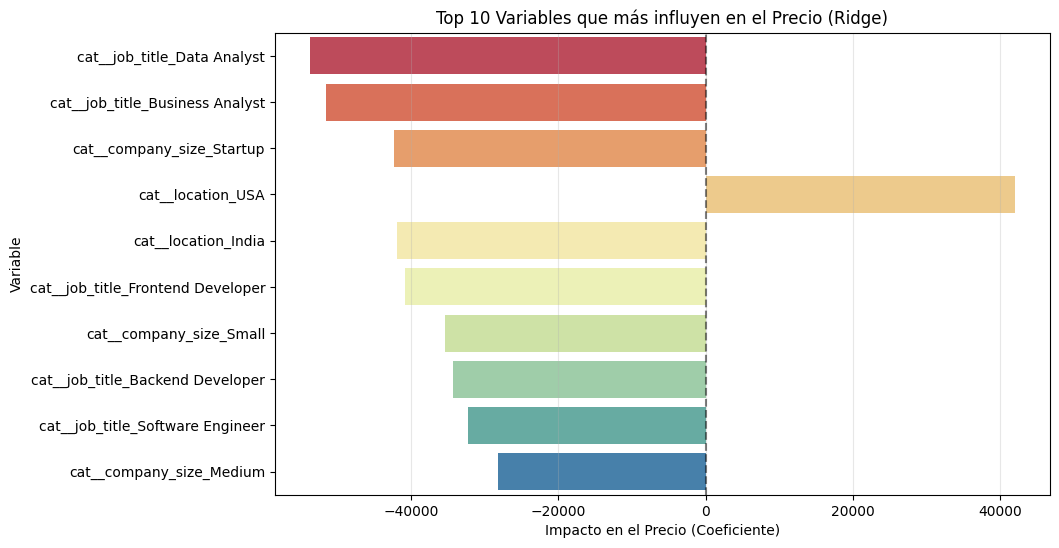

In [28]:
# 1. Extraer nombres de las columnas y coeficientes
# Usamos 'preprocessing' porque así lo nombraste en tu Pipeline
features = best_ridge.named_steps['preprocessing'].get_feature_names_out()
coeffs = best_ridge.named_steps['regressor'].coef_

# 2. Crear un DataFrame para organizar los datos
ridge_importance = pd.DataFrame({'Variable': features, 'Coeficiente': coeffs})

# Creamos una columna con el valor absoluto para saber cuáles son las más importantes (sin importar si suben o bajan el precio)
ridge_importance['Importancia_Abs'] = ridge_importance['Coeficiente'].abs()
ridge_importance = ridge_importance.sort_values(by='Importancia_Abs', ascending=False)

# 3. Graficar las 10 variables que más afectan el precio
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Coeficiente', 
    y='Variable', 
    data=ridge_importance.head(10), 
    palette='Spectral'
)
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Línea en el cero
plt.title('Top 10 Variables que más influyen en el Precio (Ridge)')
plt.xlabel('Impacto en el Precio (Coeficiente)')
plt.ylabel('Variable')
plt.grid(axis='x', alpha=0.3)
plt.show()

En el modelo Ridge, se observa que los coeficientes presentan signos negativos. Esto indica que el modelo establece un valor base (intercepto) elevado para el salario y ajusta el precio final hacia abajo según las características del empleado. Las variables con menor magnitud negativa (aquellas cuyas barras son más cortas y están más cerca del cero) representan los atributos que mejor posicionan al empleado en el mercado, mientras que las de mayor magnitud señalan los factores que el modelo penaliza con más fuerza en comparación con el promedio

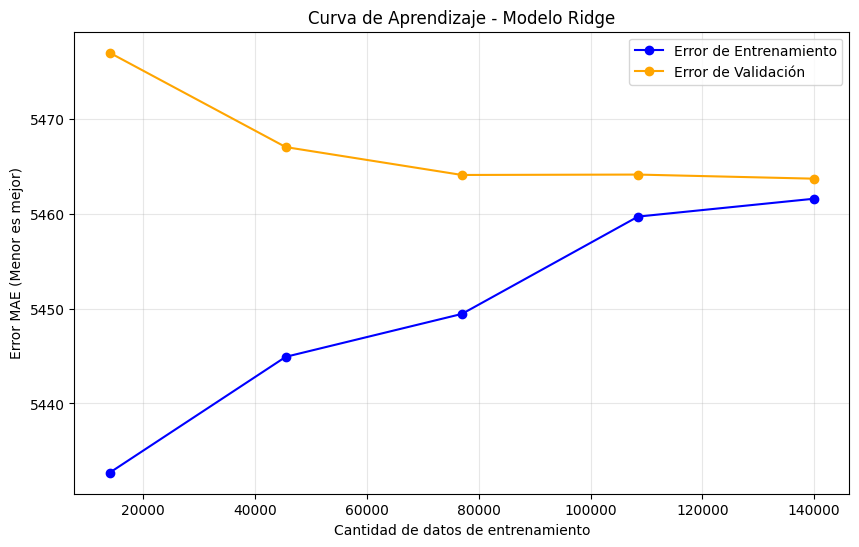

In [29]:
from sklearn.model_selection import learning_curve
import numpy as np

# 1. Calcular la curva de aprendizaje (usamos MAE como métrica de error)
train_sizes, train_scores, test_scores = learning_curve(
    best_ridge, # El modelo que ajustaste
    X_train, 
    y_train, 
    cv=5, 
    scoring='neg_mean_absolute_error', # Usamos error negativo por convención de sklearn
    train_sizes=np.linspace(0.1, 1.0, 5), # 5 cortes desde el 10% al 100% de los datos
    n_jobs=-1
)

# 2. Convertir los errores a valores positivos y calcular promedios
train_mean = -np.mean(train_scores, axis=1)
val_mean = -np.mean(test_scores, axis=1)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Error de Entrenamiento')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Error de Validación')

plt.title('Curva de Aprendizaje - Modelo Ridge')
plt.xlabel('Cantidad de datos de entrenamiento')
plt.ylabel('Error MAE (Menor es mejor)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se observa un buen ajuste en el modelo. A medida que aumenta la cantidad de datos de entrenamiento, las curvas de error de entrenamiento y validación convergen rápidamente hacia un valor similar (aprox. 4465 MAE). La ausencia de una brecha (gap) significativa entre ambas líneas indica que el modelo no sufre de sobreajuste (overfitting) y tiene una excelente capacidad de generalización para datos nuevos.